# Case Study: Food Delivery Performance Analysis 

In this project, we analyse a year's worth of food delivery orders to identify:
- Top performing cities
- Peak demand times
- Revenue drivers by cuisine
- Impact of delivery time on customer ratings

Dataset contains 12,000 orders from multiple Indian cities.


### STEP 1 — Project Setup & Data Loading

**Goal:** Import required Python libraries and load the dataset into memory.

**Why this step is important:**
Before we perform any analysis, we must bring the data into a DataFrame (tabular structure).
Libraries like Pandas and NumPy are the core tools used in almost every data analysis project.

This step ensures our dataset is ready to be explored, cleaned, and analyzed in further steps.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
path = r"C:\Users\LENOVO\Desktop\Food_Delivery_Analytics_Project\food_delivery_orders_2024.csv"
csvfile = pd.read_csv(path,parse_dates=["order_datetime"])


### STEP 2 — Understand Dataset Structure

**Goal:** Confirm dataset schema, datatypes, and missing values before doing analysis.

**Why this matters:**  
Knowing the shape and types avoids mistakes in calculations later.


In [14]:
print("Shape (rows, columns):", csvfile.shape)

print("\nColumn data types:")
print(csvfile.dtypes)

print("\nSummary of dataset:")
print(csvfile.info())

Shape (rows, columns): (12000, 14)

Column data types:
order_id                      int64
order_datetime       datetime64[ns]
customer_id                   int64
city                         object
restaurant                   object
cuisine                      object
quantity                      int64
item_price                    int64
discount                    float64
gross_amount                  int64
revenue                     float64
delivery_time_min             int64
status                       object
rating                      float64
dtype: object

Summary of dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   order_id           12000 non-null  int64         
 1   order_datetime     12000 non-null  datetime64[ns]
 2   customer_id        12000 non-null  int64         
 3   city             

### STEP 3 — Data Quality Check

**Important Part:** rating column has 11296 non-null → means ~704 rows have missing rating

**Goal:** Identify missing values and verify if dataset is clean enough for analysis.

**Why this matters:**
Data quality issues can affect our metrics, charts, and conclusions.  
So before analysis, we must detect missing values, duplicates, and irregular patterns.


In [15]:
#Count of Missing values in each column
missing_values = csvfile.isna().sum()
print("Missing Values per Column:")
print(missing_values)
#Checking If Duplicate Values Exist
duplicate_rows = csvfile.duplicated().sum()
print("\nDuplicate Rows Count:", duplicate_rows)

Missing Values per Column:
order_id               0
order_datetime         0
customer_id            0
city                   0
restaurant             0
cuisine                0
quantity               0
item_price             0
discount               0
gross_amount           0
revenue                0
delivery_time_min      0
status                 0
rating               704
dtype: int64

Duplicate Rows Count: 0


### STEP 4 — Feature Engineering (Deriving New Columns)

**Goal:** Create additional fields to enable better time-based analysis.

**Why this matters:**
Order date & time contain hidden patterns. By extracting hour, day, and month, we can analyze peak demand, weekday trends, and seasonal patterns — which are crucial for operations and marketing decisions.

We will create:
- order_month
- order_day_of_week
- order_hour
- is_peak_hour (Lunch/Dinner)


In [16]:
# Creating new columns from order_datetime
csvfile['order_month'] = csvfile['order_datetime'].dt.month
csvfile['order_day_of_week'] = csvfile['order_datetime'].dt.day_name()
csvfile['order_hour'] = csvfile['order_datetime'].dt.hour

## Identify lunch and dinner rush periods
csvfile['is_peak_hour'] = csvfile['order_hour'].between(12,14) | csvfile['order_hour'].between(19,22)
csvfile.head()


,order_id,order_datetime,customer_id,city,restaurant,cuisine,quantity,item_price,discount,gross_amount,revenue,delivery_time_min,status,rating,order_month,order_day_of_week,order_hour,is_peak_hour
0,4793,2024-01-01 18:40:00,17569,Mumbai,Andheri Spice,Pizza,1,450,0.10,450,403.25,33,Delivered,5.0,1,Monday,18,False
1,4534,2024-01-01 19:40:00,15975,Pune,Burger Bay PNE,Chinese,4,300,0.02,1200,1177.71,39,Delivered,4.0,1,Monday,19,True
2,2514,2024-01-01 20:30:00,12482,Bengaluru,Darshini Express,Biryani,3,320,0.07,960,892.59,28,Delivered,4.4,1,Monday,20,True
3,10878,2024-01-01 20:50:00,11262,Chennai,Adyar Ananda,South Indian,4,220,0.10,880,790.87,44,Delivered,4.1,1,Monday,20,True
4,2473,2024-01-01 21:00:00,11717,Hyderabad,Chinese Bowl HYD,Biryani,2,320,0.03,640,618.30,28,Delivered,4.2,1,Monday,21,True


### STEP 5 — Business KPI Summary

**Goal:** Compute high-level performance metrics for the food delivery business.

**Why this matters:**
These KPIs help identify overall business health before drilling into detailed analysis.  
They are the same metrics that stakeholders and leadership want to see first in any analytics report.

In [17]:
# Total number of orders
total_orders = len(csvfile)

# Total revenue
total_revenue = csvfile['revenue'].sum()

# Average delivery time
avg_delivery_time = csvfile['delivery_time_min'].mean()

# Cancellation Rate = Cancelled / Total * 100
cancellation_rate = (csvfile[csvfile['status'] == 'Cancelled'].shape[0] / total_orders) * 100

# Average rating (Only for delivered orders)
avg_rating = csvfile[csvfile['status'] == 'Delivered']['rating'].mean()

kpi_summary = {
    "Total Orders": total_orders,
    "Total Revenue": total_revenue,
    "Avg Delivery Time (min)": avg_delivery_time,
    "Cancellation Rate (%)": cancellation_rate,
    "Avg Rating (Delivered only)": avg_rating
}

print("KPI Summary:\n")
for k, v in kpi_summary.items():
    print(f"{k}: {v:.2f}")

KPI Summary:

Total Orders: 12000.00
Total Revenue: 9273546.19
Avg Delivery Time (min): 34.90
Cancellation Rate (%): 4.03
Avg Rating (Delivered only): 4.30


### STEP 6 — Orders by City (Top Performing Locations)

**Goal:** Identify which cities generate the highest number of orders.

**Why this matters:**
City-wise demand helps management decide where to invest more delivery resources, offer promotional campaigns, and prioritize restaurant partnerships.

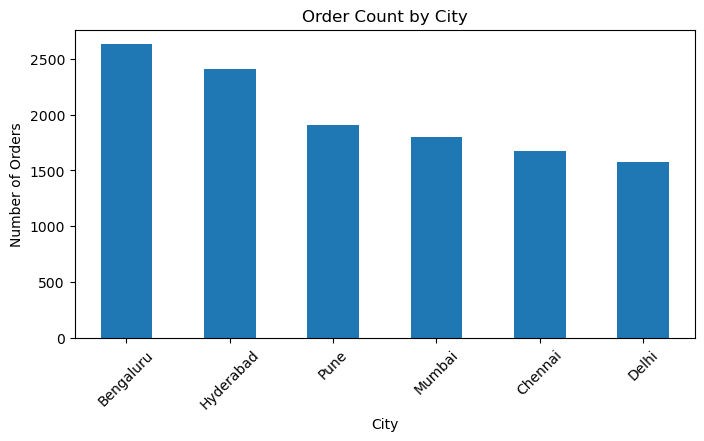

city
Bengaluru    2631
Hyderabad    2406
Pune         1909
Mumbai       1803
Chennai      1676
Delhi        1575
Name: count, dtype: int64

In [18]:
# Group by city and count orders
city_order_count = csvfile['city'].value_counts().sort_values(ascending=False)

# Plot
plt.figure(figsize=(8,4))
city_order_count.plot(kind='bar')
plt.title("Order Count by City")
plt.xlabel("City")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

city_order_count

### STEP 7 — Revenue Contribution by Cuisine

**Goal:** Identify which cuisine types generate the highest revenue.

**Why this matters:**  
Revenue contribution by cuisine helps decide which type of restaurants to partner with more aggressively and which cuisine categories drive business profitability.


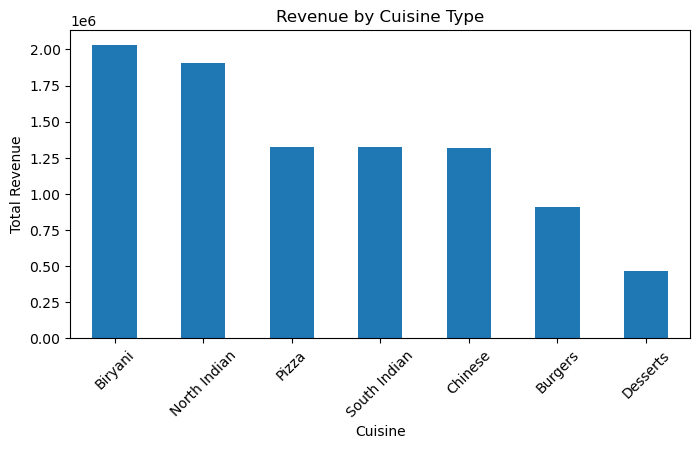

cuisine
Biryani         2033567.94
North Indian    1904290.20
Pizza           1325074.36
South Indian    1323150.38
Chinese         1315268.19
Burgers          909674.22
Desserts         462520.90
Name: revenue, dtype: float64

In [20]:
# Group revenue by cuisine and sort descending
cuisine_revenue = csvfile.groupby('cuisine')['revenue'].sum().sort_values(ascending=False)

# Plot revenue by cuisine
plt.figure(figsize=(8,4))
cuisine_revenue.plot(kind='bar')
plt.title("Revenue by Cuisine Type")
plt.xlabel("Cuisine")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

cuisine_revenue
#1e6 means: All y-axis values are in millions

### STEP 8 — Hourly Order Demand Trend

**Goal:** Understand which hours of the day see the highest number of orders.

**Why this matters:**  
Identifying demand peaks helps in optimizing delivery partner allocation, restaurant staffing, and targeted time-based discount campaigns.

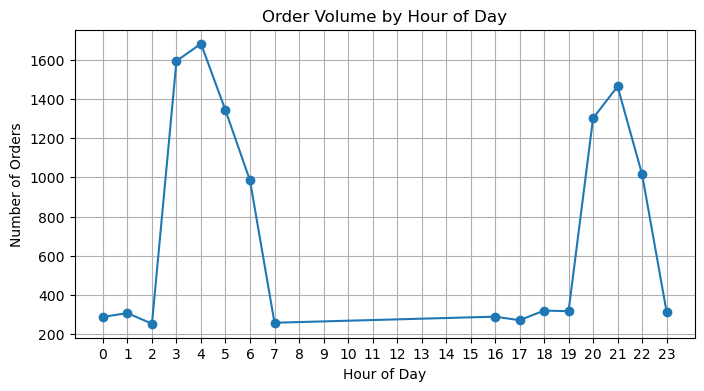

order_hour
0      288
1      307
2      253
3     1594
4     1682
5     1342
6      984
7      258
16     289
17     271
18     320
19     317
20    1302
21    1464
22    1015
23     314
Name: order_id, dtype: int64

In [22]:
# Group by hour and count orders
hourly_orders = csvfile.groupby('order_hour')['order_id'].count()

plt.figure(figsize=(8,4))
hourly_orders.plot(kind='line', marker='o')
plt.title("Order Volume by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.xticks(range(0,24))
plt.grid()
plt.show()

hourly_orders

### STEP 9 — Delivery Time Impact on Customer Rating

**Goal:** Check if longer delivery time affects customer ratings.

**Why this matters:**  
Understanding this relationship helps operational teams improve delivery SLAs and reduce customer dissatisfaction.

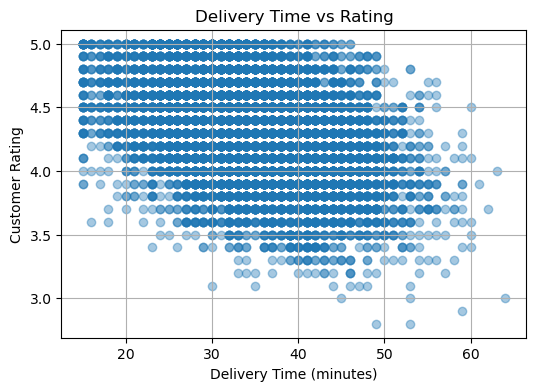

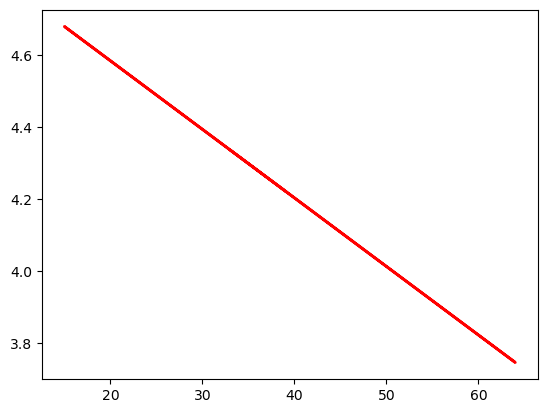

In [26]:
# Filtering only delivered orders since cancelled have no useful rating context
delivered_orders = csvfile[csvfile['status'] == 'Delivered']

plt.figure(figsize=(6,4))
plt.scatter(delivered_orders['delivery_time_min'], delivered_orders['rating'], alpha=0.4)
plt.title("Delivery Time vs Rating")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Customer Rating")
plt.grid(True)
plt.show()
x = delivered_orders['delivery_time_min']
y = delivered_orders['rating']

# Linear best fit line
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red', linewidth=2)